# Telecom Customer Churn Analysis

## 04: Multivariate Analysis and Customer Churn

### Objective

This notebook investigates how multiple customer characteristics, service usage patterns, and account factors interact in relation to customer churn.

The analysis focuses on:

- Examining how tenure and contract type interact in relation to churn
- Investigating how internet type, service subscriptions, and billing characteristics relate to churn when considered together
- Exploring how customer profile characteristics and tenure interact with churn
- Identifying combined patterns that may provide additional insight beyond individual bivariate relationships

This builds on the bivariate analysis by examining multiple variables together to better understand how customer characteristics and behaviors interact in relation to churn.

# Telecom Customer Retention & Churn Dynamics Analysis

## 04: Multivariate Analysis

### Objective
This notebook examines how multiple variables interact simultaneously to amplify risk or provide protective retention buffers.

The multivariate exploration process includes:
- Analyzing whether long-term contracts protect against the high churn observed in expensive monthly tiers to identify how to expand revenue safely.
- Testing whether bundling protection add-ons like Online Security and Premium Tech Support neutralizes the elevated Fiber Optic churn rate to pinpoint actionable service packages.
- Crossing promotional campaigns with tenure cohorts and contract structures to isolate whether early-tenure exits are campaign-driven or onboarding-driven.
- Evaluating how vulnerable customer cohorts like Seniors and solo households interact with payment methods, digital billing channels, and referral programs.
- Evaluating correlation matrices across continuous variables such as tenure, monthly charges, total revenue, and usage metrics to understand cumulative financial impact and check for multicollinearity.

The resulting insights will directly substantiate the strategic recommendations and interventions presented in the final project report.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_parquet('../data/processed/telecom_customer_churn_engineered.parquet')

sns.set_theme(style='white', 
              context='notebook', 
              palette='deep')

plt.rcParams['figure.figsize'] = (5, 3)
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlepad'] = 16
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.labelpad'] = 6
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

### Contract Insulation vs Price Sensitivity
Test whether contract commitments shield against high-tier monthly charge churn.

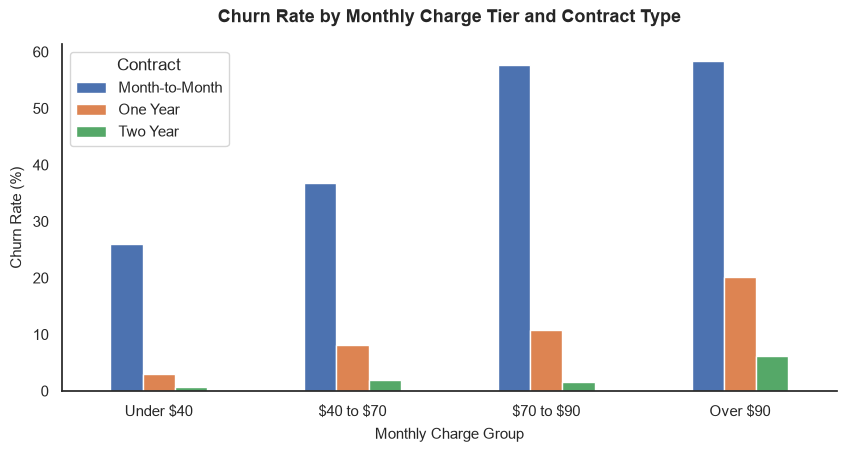

In [32]:
charge_bins = [-1, 40, 70, 90, df['Monthly Charge'].max()]
charge_labels = ['Under $40', r"\$40 to \$70", r'\$70 to \$90', 'Over $90']

df['Charge Group'] = pd.cut(
    df['Monthly Charge'],
    bins=charge_bins,
    labels=charge_labels
)

df['Is Churned'] = (df['Customer Status'] == 'Churned').astype(int)

charge_contract_churned = df.pivot_table(
    index='Contract',
    columns='Charge Group',
    values='Is Churned',
    aggfunc='mean'
) * 100

ax = charge_contract_churned.T.plot(
    kind='bar',
    figsize=(10, 4.5),
    rot=0
)

plt.title('Churn Rate by Monthly Charge Tier and Contract Type')
plt.xlabel('Monthly Charge Group')
plt.ylabel('Churn Rate (%)')
plt.legend(title='Contract');


#### Key Takeaways: Contract Insulation vs Price Sensitivity
- **Price-Sensitive Month-to-Month Surge:** Month-to-Month churn scales directly with pricing.
- **Contract Insulation Below $90:** Long-term commitments effectively suppress churn across lower-to-mid price tiers; even in the $70 to $90 range, One-Year contracts see only ~10% churn and Two-Year contracts stay negligible at ~1.5%.
- **High-Tier Commitment Erosion:** Contract insulation begins to show friction once charges exceed $90, with One-Year churn doubling to ~20% and Two-Year churn climbing to ~6%.
- **Structural Contract Divergence:** Regardless of the billing tier, Month-to-Month subscribers consistently churn at multiples higher than long terms contracts, cementing contract structure as the primary buffer against price-driven attrition.

### Fiber Optic Support Matrix & Add-on Adoption Depth
Evalate whether value-added protection add-ons neutralize Fiber Optic churn.

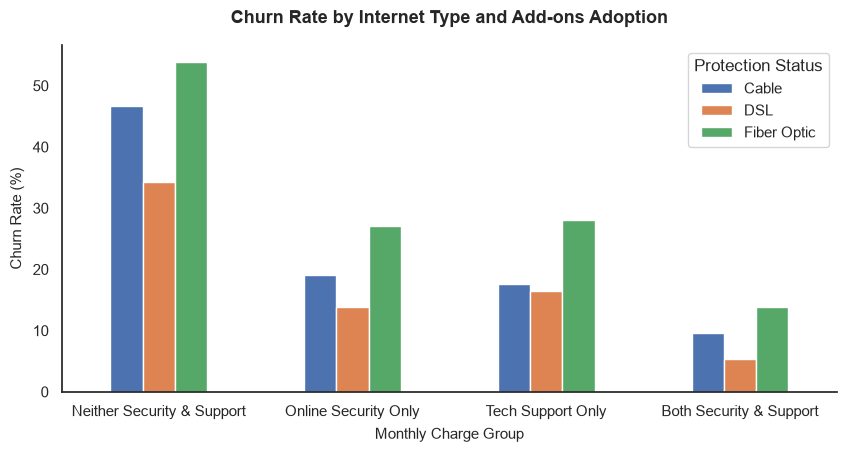

In [52]:
internet_df = df[df['Internet Service'] == 1].copy()

conditions = [
    (internet_df['Online Security'] == 1) & (internet_df['Premium Tech Support'] == 1),
    (internet_df['Online Security'] == 1) & (internet_df['Premium Tech Support'] != 1),
    (internet_df['Online Security'] != 1) & (internet_df['Premium Tech Support'] == 1),
]

choices = ['Both Security & Support', 'Online Security Only', 'Tech Support Only']

internet_df['Protection Status'] = np.select(conditions, choices, default='Neither Security & Support')

protection_churn = internet_df.pivot_table(
    index='Internet Type',
    columns='Protection Status',
    values='Is Churned',
    aggfunc='mean'
) * 100

cols_order = [
    'Neither Security & Support',
    'Online Security Only',
    'Tech Support Only',
    'Both Security & Support'
]

protection_churn = protection_churn.reindex(columns=cols_order).round(1)

ax = protection_churn.T.plot(
    kind='bar',
    figsize=(10, 4.5),
    rot=0
)

plt.title('Churn Rate by Internet Type and Add-ons Adoption')
plt.xlabel('Monthly Charge Group')
plt.ylabel('Churn Rate (%)')
plt.legend(title='Protection Status');


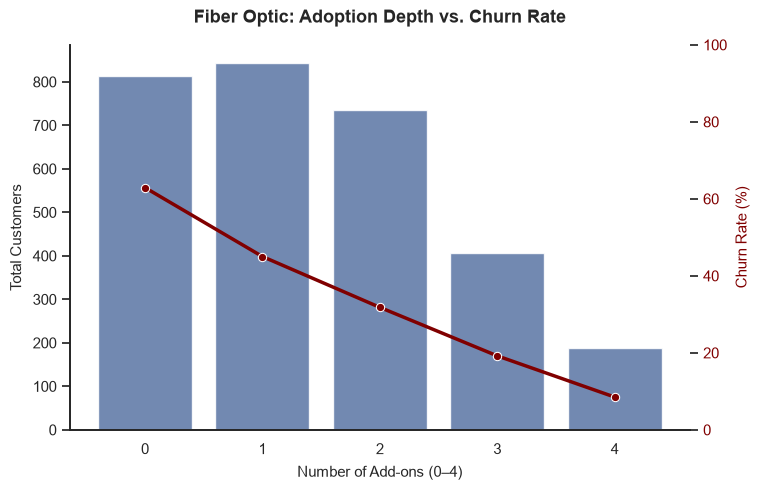

In [53]:
fiber_df = internet_df[internet_df['Internet Type'] == 'Fiber Optic'].copy()

protection_cols = ['Online Security', 'Premium Tech Support', 'Online Backup', 'Device Protection Plan']

fiber_df['Addons Count'] = fiber_df[protection_cols].sum(axis=1)

fiber_adoption = (
    fiber_df.groupby('Addons Count')['Is Churned']
    .agg(
        Total_Customers='count',
        Churned_Customers='sum',
        Churn_Rate=lambda x: round(x.mean() * 100, 1),
    )
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=fiber_adoption,
    x='Addons Count',
    y='Total_Customers',
    ax=ax1,
    alpha=0.85,
)
ax1.set_xlabel('Number of Add-ons (0–4)')
ax1.set_ylabel('Total Customers')
ax1.tick_params(axis='y')

ax2 = ax1.twinx()
sns.lineplot(
    data=fiber_adoption,
    x='Addons Count',
    y='Churn_Rate',
    marker='o',
    linewidth=2.5,
    ax=ax2,
    color='maroon'
)
ax2.set_ylabel('Churn Rate (%)', color='maroon')
ax2.tick_params(axis='y', labelcolor='maroon')
ax2.set_ylim(0, 100)

plt.title('Fiber Optic: Adoption Depth vs. Churn Rate')
plt.grid(False)

#### Key Takeaways: Fiber Optic Support Matrix & Add-on Adoption Depth

- **Protection Deficit Vulnerability:** Unprotected Fiber Optic subscribers exhibit the most severe attrition across all segments, peaking above 50% churn when lacking both Security and Support add-ons.
- **Equal Protective Buffering:** Individual adoption of either Online Security or Tech Support slashes Fiber Optic churn by roughly half, showing nearly identical retention efficacy between the two standalone services.
- **Compounded Suite Retention:** Subscribing to both Security and Tech Support compresses Fiber Optic churn down to ~14%, bringing high-risk fiber customers closer in line with lower-churn tiers.
- **Linear Attrition Reduction by Adoption Depth:** Churn rate follows a strict inverse relationship with add-on depth, dropping linearly from over 60% at zero add-ons down to under 10% when all four protection services are active.
- **Adoption Distribution Imbalance:** The vast majority of Fiber Optic subscribers are concentrated in the high-risk 0 to 2 add-on tiers, while the ultra-low-churn cohort holding 3 or 4 add-ons accounts for only a minor fraction of the total subscriber base.

### Household & Demographic Risk Factors
- Measure how family anchors, referrals, and payment channels impact vulnerable customer segments.

In [73]:
payments_friction = (
    df.groupby(['Age Group', 'Payment Method', 'Paperless Billing'])['Is Churned']
    .agg(Total_Customers='count', Churn_Rate=lambda x: round(x.mean() * 100, 1))
    .reset_index()
)

payments_friction

,Age Group,Payment Method,Paperless Billing,Total_Customers,Churn_Rate
0,Young Adult,Bank Withdrawal,0,386,17.6
1,Young Adult,Bank Withdrawal,1,698,36.2
2,Young Adult,Credit Card,0,478,9.8
3,Young Adult,Credit Card,1,448,15.4
4,Young Adult,Mailed Check,0,67,26.9
5,Young Adult,Mailed Check,1,59,50.8
6,Middle-Aged,Bank Withdrawal,0,360,20.0
7,Middle-Aged,Bank Withdrawal,1,644,37.6
8,Middle-Aged,Credit Card,0,431,6.0
9,Middle-Aged,Credit Card,1,373,17.7


In [ ]:
tech_support_senior = (
    internet_df.groupby(['Age Group', 'Premium Tech Support'])['Is Churned']
    .agg(
        Total_Customers='count',
        Churn_Rate=lambda x: round(x.mean() * 100, 1)
    )
    .reset_index()
)

tech_support_senior

,Age Group,Premium Tech Support,Total_Customers,Churn_Rate
0,Young Adult,0,957,36.3
1,Young Adult,1,659,14.6
2,Middle-Aged,0,861,39.8
3,Middle-Aged,1,568,14.4
4,Pre-Senior,0,843,40.8
5,Pre-Senior,1,535,15.5
6,Senior,0,756,51.1
7,Senior,1,244,19.7


In [ ]:
early_tenure_df = df[df['Tenure Group'] == '0-6 Months']

referral_buffering = (
    early_tenure_df.groupby('Number of Referrals')['Is Churned']
    .agg(
        Total_Customers='count',
        Churn_Rate=lambda x: round(x.mean() * 100, 1)
    )
    .reset_index()
)

referral_buffering

,Number of Referrals,Total_Customers,Churn_Rate
0,0,1158,53.9
1,1,151,76.2
2,2,13,23.1
3,3,25,40.0
4,4,15,53.3
5,5,18,27.8
6,6,9,11.1
7,7,9,0.0
8,8,15,6.7
9,9,18,0.0


#### Key Takeaways: Household & Demographic Risk Factors

- **Paperless Billing Increases Churn Everywhere:** Turning on paperless billing leads to higher cancellation rates for every age group, usually adding 7% to 19% to the churn rate compared to paper bills.
- **Credit Cards Keep Customers Longest:** Paying by credit card with regular paper bills produces the lowest cancellation rates across the board (only 6% for middle-aged users, around 9%–10% for younger groups, and under 29% for seniors).
- **Seniors Face the Highest Overall Risk:** Older customers leave at much higher rates regardless of payment setup. Nearly half of all seniors using bank withdrawal with paperless billing cancel their service.
- **Mixing Paperless with Mailed Checks Fails:** Customers who choose paperless billing but still pay by mailed check cancel at alarming rates at roughly 50% across almost every age bracket.

# Multivariate Synthesis: Churn Drivers & Behavioral Vulnerabilities

- **Contracts Shield Against Price Sensitivity:** Month-to-month users cancel rapidly as bills increase, but contracts keep churn very low below $90. Once bills cross $90, even committed customers start leaving, doubling 1-year churn to ~20%.
- **Fiber Without Add-ons Is a Churn Trap:** Bare fiber optic plans see the worst cancellations, peaking above 50%. Adding either Tech Support or Online Security cuts churn in half, while pairing both drives it down to ~14%. Each extra add-on steadily drops churn from over 60% down to under 10%, yet most fiber users remain dangerously stuck at 0 to 2 add-ons.
- **Digital Billing Sparks Unexpected Exits:** Paperless billing hurts retention across all age groups. The highest churn hits seniors on bank withdrawal (~49%) and anyone pairing paperless billing with mailed checks (~50%), pointing to clear payment friction.
- **Credit Cards Provide the Strongest Floor:** Auto-paying via credit card with paper bills yields the best retention across every demographic, keeping churn as low as 6% to 10% for non-seniors and under 29% for seniors.